In [2]:
import numpy as np
import random
from functools import reduce
from itertools import chain, combinations, product, repeat
from scipy import linalg, sparse
import matplotlib.pyplot as plt
import os
from scipy.stats import unitary_group
import time 
from toqito.channels import partial_trace

In [3]:
# Gates:

Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')
paulis = [Id2, S_X, S_Y, S_Z]/np.sqrt(2)
basis4by4=np.kron(paulis,paulis)


def inner(X,Y):
    if type(X)!=np.ndarray:
        X=X.toarray()
        Y=Y.toarray()
    prod=np.trace(X.T.conj()@Y)
    return prod
    
# uniform-U(4) matrices:
# checked that the eigenvalue distribution is uniform
def mkU(n):
    Un = (np.random.random([n,n]) + 1j* np.random.random([n,n]))/np.sqrt(2)
    q,r = linalg.qr(Un)
    #d = np.diag(r)
    #ph = d/abs(d)
    #q = q * ph * q   
    return q

""" TO DO
check the difference between this function and x=unitary_group.rvs(3)
and the Gaussian unitary ensemble
"""


def mkLiouvillian(rate, dt, ldbldOp): 
    # Not sure how to include an environment qutrit and maintain unitarity

    L1 = np.kron(np.sqrt(rate/2) *ldbldOp, np.eye(2))
    L2 = np.kron(np.eye(2), np.sqrt(rate/2) *ldbldOp)
    
    h = -1j * linalg.logm(unitary_group.rvs(4)) #- (np.kron(ldbldOp, np.eye(2)) + np.kron(np.eye(2), ldbldOp))
    
    H =  (np.kron(h.conj(), np.eye(4)) - np.kron(np.eye(4), h) )
    
    #print(np.allclose(H, H.T.conj()))
    lindblads = [L1,L2]
    
    G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
    for L in lindblads:
        G += np.kron(L.conj(), L) - 1/2 * np.kron(np.eye(len(L)), L.T.conj()@L) - 1/2 * np.kron(L.T@L.conj(), np.eye(len(L)))
        
    # print(np.allclose(G, G.T.conj()) )
    denseU=linalg.expm( (-1j*H + G) * dt)
    
    return denseU # to act on the vectorized density matrix of 2 qubits

def mkKrausOps(U): 
    X = np.reshape(np.transpose(np.reshape(U,[4]*int(np.log2(len(U)))),[0,2,1,3]),list(U.shape))   
    [eigVals, eigVecs] = linalg.eigh(X)
    
    krausOps=[]
    
    for i in range(len(U)):
        if abs(eigVals[i])>1e-10:
            krausOps = krausOps + [ sparse.csr_matrix(np.sqrt(eigVals[i]) * np.reshape(eigVecs[:,i],[4,4]))]
            
    return krausOps


def decompKrausOps(krausOps):
    # for each kraus operator, there is a set of k_abs that
    # stores the inner product of each on-site kraus ops with the basis in a row
    
    k_abs=np.array([[] for i in range(16)],dtype='complex128').T
    for (k,op) in enumerate(krausOps):
        k_temp = np.zeros(len(basis4by4),dtype='complex128')
        for (i,b) in enumerate(basis4by4):
            k_temp[i] = inner(b, op)
        k_abs = np.vstack([k_abs,k_temp])
        
    return k_abs


In [4]:
# at layers where PBC is not needed
def mkGlobalKrausOps(layer, Nqubit, rate, dt, ldbldOp, debug=True):
    
    allKs = {}

    if np.mod(layer,2) == 0:    
        # position records the site with the non-trivial unitary
        
        positions = [i for i in range(0, Nqubit-1, 2)]
        
        for pos in positions:
            
            # one needs to make N/2 different random unitaries 
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp=S_Z))
            allKs[pos] = []

            for i in range(len(krausOps)):
                U_chain = chain(repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
                allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))
        
        for pos in positions:  
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp))
            allKs[pos] = []
            
            if pos < Nqubit-1:

                for i in range(len(krausOps)):
                    U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                    allKs[pos] += [reduce(sparse.kron, U_chain)]
                    
            else:
                # decomposition of Kraus is required with PBC
                
                k_abs = decompKrausOps(krausOps)
                
                for row in k_abs:

                    K_jk = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):  
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128') 
                        U_chain[pos] = paulis[basisInd//4] 
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)] 

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]   

    return allKs

In [5]:
# employ the faster Kraus Unitary sum
def evolveKrausU(allKs, rho, debug = False):
    
    Nqubit = int(np.log2(len(rho.toarray())))
 
    newRho = rho
    for key in allKs.keys():
        rho = newRho
        newRho = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit]) )

        for mat in allKs[key]:
            newRho += mat @ rho @ mat.T.conj()   
            
            #if debug == True:
            #    print(np.trace(newRho.toarray()))
        
    return newRho


# make measurement  (something is wrong with this thing)

def mkS_zMsm(probMsm, rho , debug = False):
    
    Nqubit = int(np.log2(len(rho.toarray())))
    sites = [n for n in range(Nqubit)]
    randomNumbers = np.random.uniform(0,1,Nqubit)
    msmSites = np.where(randomNumbers < probMsm)[0]

    if list(msmSites) !=[]:

        Projs = [
            (np.eye(2)+S_Z)/2, 
            (np.eye(2)+(-1)*S_Z)/2
        ]

        numMsSites=len(msmSites)
        
        # make one projection msm at a time:
        for (j,ms) in enumerate(msmSites):  
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[0]
            proj0p = reduce(sparse.kron, proj_chain)
            
            if debug == True: print(proj_chain)
            
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[1]
            proj1p = reduce(sparse.kron, proj_chain)
            
            if debug == True: print("projector", proj0p.shape, " rho", rho.shape)

            # probability of having one of the outcomes
            prob = np.trace((proj0p @ rho @ proj0p.T.conj()).toarray())
            
            if np.random.random(1) < prob:
                testRho = (proj0p @ rho @ proj0p.T.conj())/prob
                
            else:
                testRho = (proj1p @ rho @ proj1p.T.conj())/(1-prob)

            #if debug: 
            #    print(np.trace(testRho.toarray()))
            #    print(proj_chain)
                
            # One needs to keep track of the measurement!!!
            rho = testRho

    else:
        testRho = rho

    return testRho 


In [6]:
def ensSAvgroutine(N_ens, Nqubit, rate, probMsm, dt, steps, debug = False):
        
    ensembleS = np.zeros([rep,steps])
    ensembleP = np.zeros([rep,steps])
    
    # Pure state start
    state0 = (qb[0] + qb[1])/np.sqrt(2)
    state0rho = np.outer(state0, state0)

    for e in range(N_ens):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))
        for s in range(steps):
            allKrausOps = mkGlobalKrausOps(s, Nqubit, rate, dt, S_Z, debug)
            
            if debug == True: print(s, Nqubit)
            rho = evolveKrausU(allKrausOps, rho)
            
            if debug == True: print('rho dim = ', np.shape(rho))
            rho = mkS_zMsm(probMsm, rho)
            ensembleS[e,s] = calcS(rho.toarray(), partiesToTraceOut=list(range(1,Nqubit//2)))
            ensembleP[e,s] = calcPurity(rho.toarray())

    ensSAvg = np.average(ensembleS ,axis=0)
    ensPAvg = np.average(ensembleS ,axis=0)
            
    return ensSAvg,ensPAvg


In [7]:
def calcS(densityM, partiesToTraceOut=[1]):
    Ntot=int(np.log2(densityM.shape[0]))
    redRho = partial_trace(densityM, partiesToTraceOut, [2]* Ntot)
    eVals = np.linalg.eigvalsh(redRho)
    eVals = eVals[np.where(eVals>1e-12)]
    S = -sum(eVals*np.log2(eVals))
    return S

def calcPurity(densityM):
    purity = np.trace(densityM@densityM)
    return purity
    

In [8]:
import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep',style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [4]:
# Testing einsum partial trace function:

def ptrace_rho(rho, elements):
    elems = set(elements)
    counter = 0
    indexarr = []
    for i in range(len(rho.shape)//2):
        if i in elems:
            indexarr += [counter,counter]
            counter += 1
        else:
            indexarr += [counter,counter+1]
            counter += 2
    print(indexarr)
    return np.einsum(rho, indexarr)

In [ ]:
qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')



In [ ]:
# Now check jump rates

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

t_total = 200
dt=5
steps = int(t_total/dt)
rep = 20

# Variables to loop through
NList = [4, 6, 8, 10]
rateList = np.logspace(-5,1,4) # [1.e-05, 1.e-03, 1.e-01, 1.e+01]
probList = [0, .05, .1, .15, .3, .4]


avgedS_dynamics = {}
avgedS_steady = {}

avgedP_dynamics = {}
avgedP_steady = {}

for rate in rateList:
    avgedS_dynamics[rate] = {}
    avgedS_steady[rate] = {}
    
    avgedP_dynamics[rate] = {}
    avgedP_steady[rate] = {}

    for probMsm in probList:
        
        avgedS_dynamics[rate][probMsm] = {}
        avgedS_steady[rate][probMsm] = np.zeros(len(NList))
        
        avgedP_dynamics[rate][probMsm] = {}
        avgedP_steady[rate][probMsm] = np.zeros(len(NList))

        startTime = time.time()

        for (ind, N) in enumerate(NList):

            avgedS_dynamics[rate][probMsm][N], avgedP_dynamics[rate][probMsm][N] = ensSAvgroutine(rep, N, rate, probMsm, dt, jumpOp steps, False)    
            avgedS_steady[rate][probMsm][ind] = np.average(avgedS_dynamics[rate][probMsm][N][steps//2:])
            avgedP_steady[rate][probMsm][ind] = np.average(avgedP_dynamics[rate][probMsm][N][steps//2:])

            print('rate=', rate, ', p=', probMsm, ', time=', time.time()-startTime)


In [51]:
import pickle

with open('avgedS_dynamics.pkl','wb') as f:
    pickle.dump(avgedS_dynamics,f)

with open('avgedS_steady.pkl','wb') as f:
    pickle.dump(avgedS_steady,f)


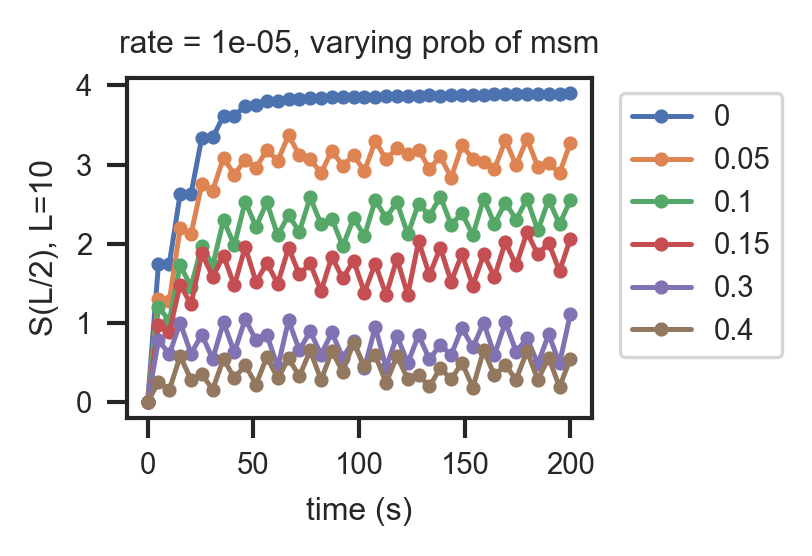

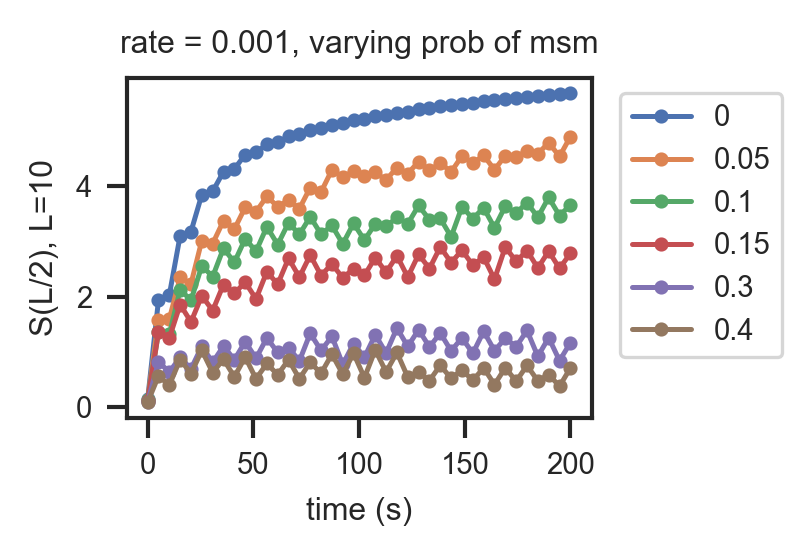

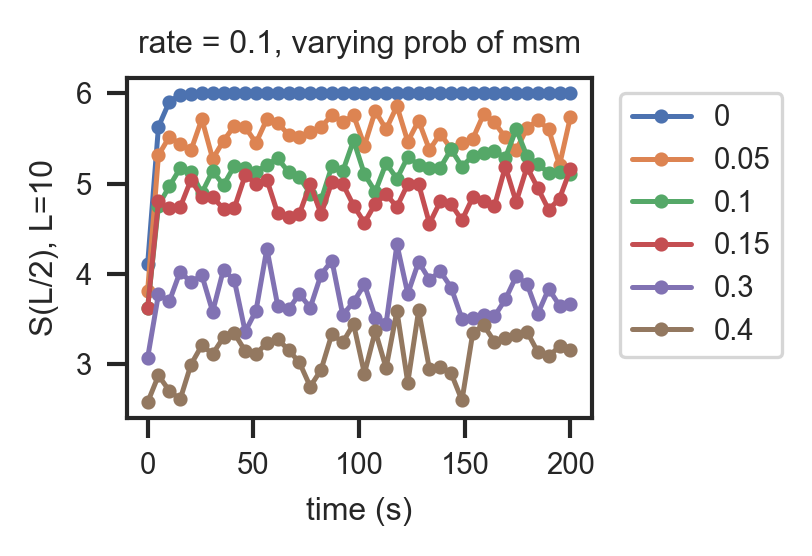

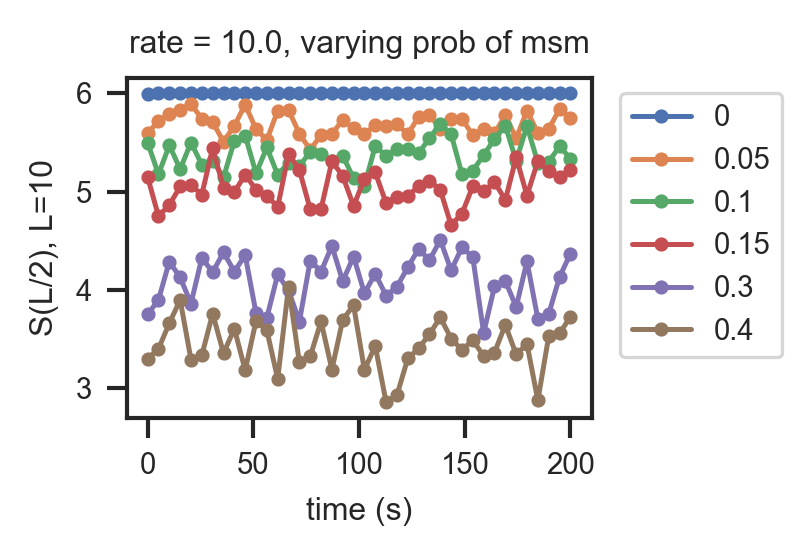

In [50]:
duration = np.linspace(0,t_total,int(t_total/dt))

for rates in avgedS_dynamics.keys():
    plt.figure()
    for prob in list(avgedS_dynamics[rates].keys()):
        plt.plot(duration,avgedS_dynamics[rates][prob][10],'.-')
        plt.xlabel('time (s)')
    plt.ylabel('S(L/2), L=10')
    plt.title('rate = ' + str(rates) + ', varying prob of msm')
    plt.legend(probList,bbox_to_anchor= (1.03, 1) )



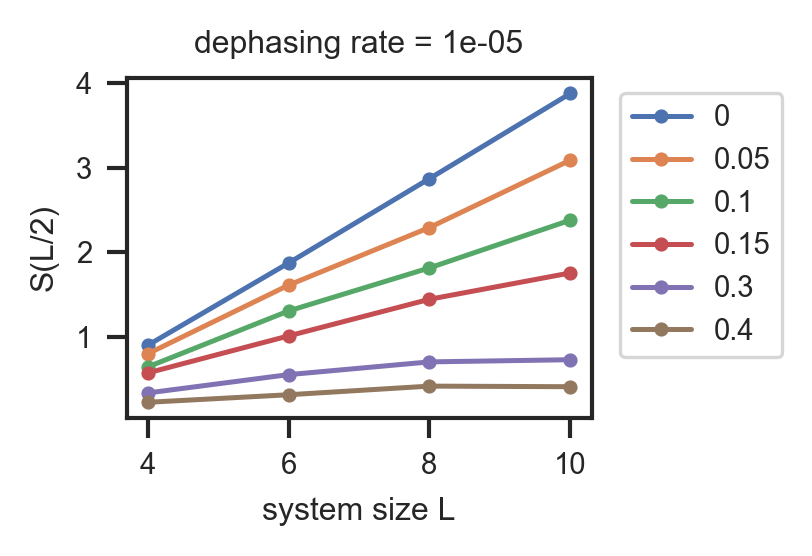

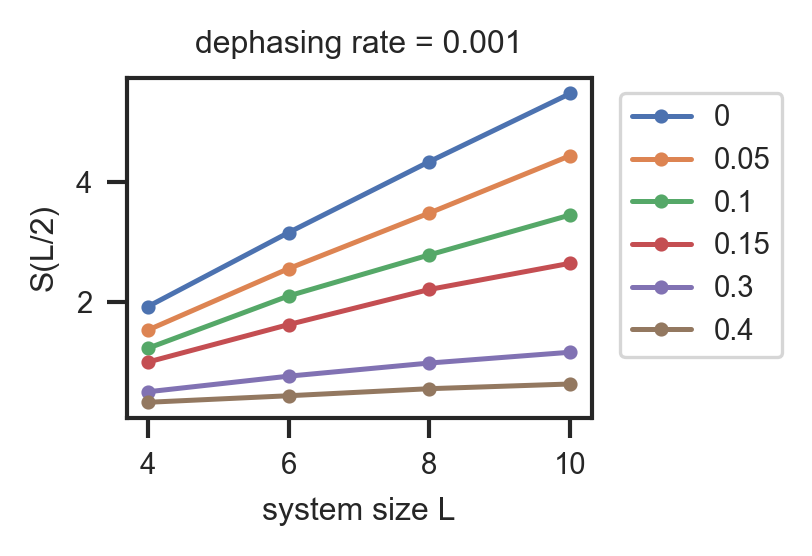

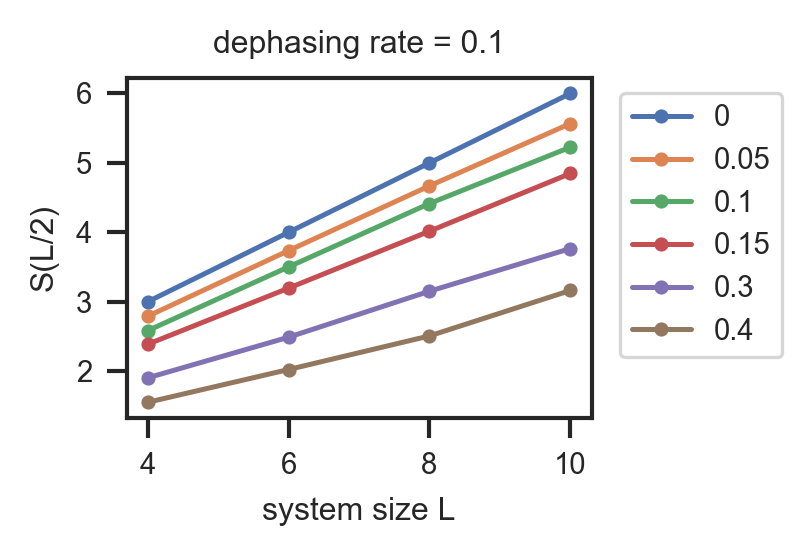

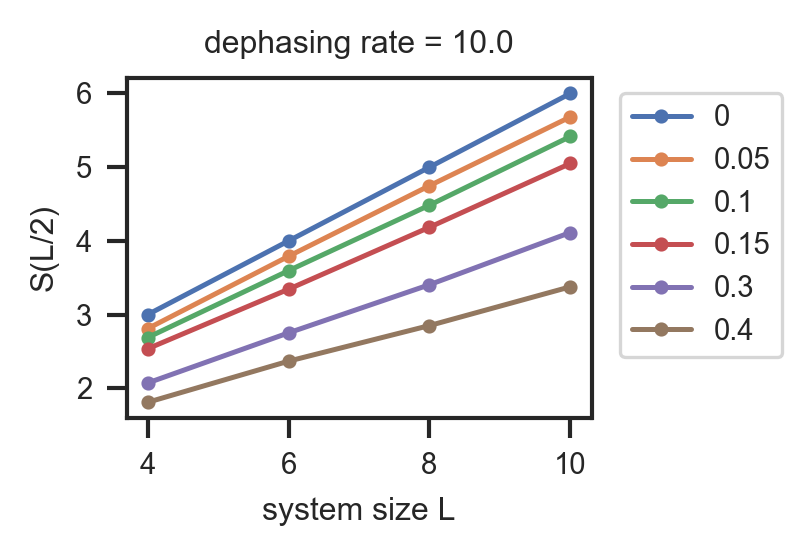

In [52]:
for rates in avgedS_steady.keys():
    plt.figure()
    for prob in list(avgedS_steady[rates].keys()):
        plt.plot(np.array(NList),avgedS_steady[rates][prob],'.-')
        plt.xlabel('system size L')
        plt.ylabel('S(L/2)')
        plt.title('dephasing rate = ' + str(rates))
        plt.legend(probList,bbox_to_anchor= (1.03, 1))
    

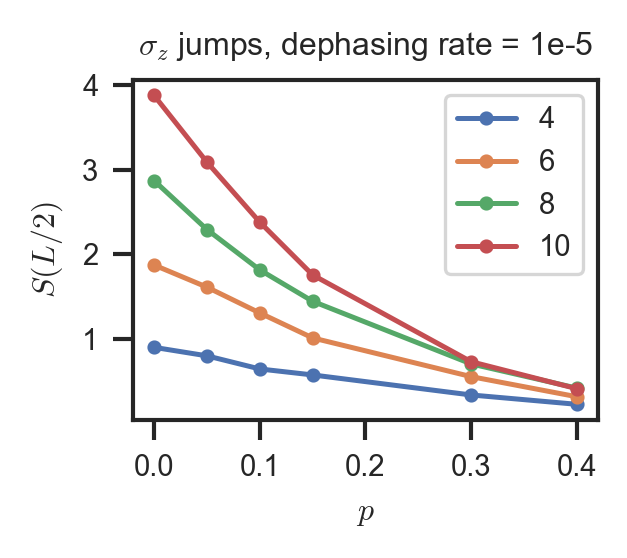

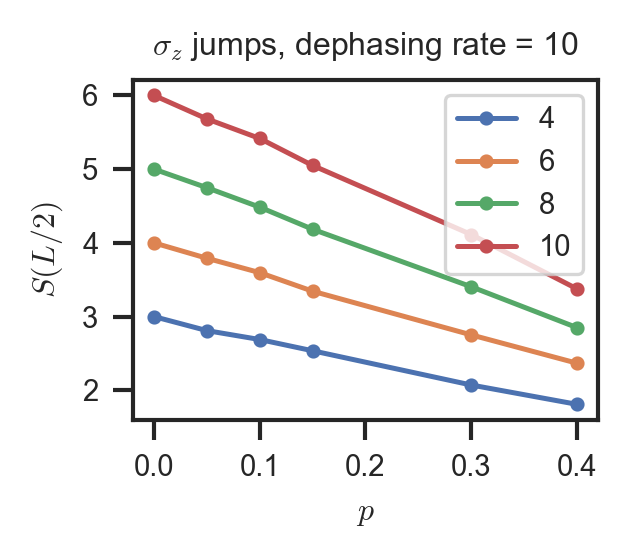

In [67]:
# Just take the L=10 data and see how things scale with p

plt.figure()

rates = 1e-5
for (n,N) in enumerate(NList):
    S=np.zeros(len(probList))
    for (i,prob) in enumerate(list(avgedS_steady[rates].keys())):
        S[i] = avgedS_steady[rates][prob][n]        
    plt.plot(np.array(probList), S,'.-')
    plt.xlabel('$p$')
    plt.ylabel('$S(L/2)$')
    plt.title(r'$\sigma_z$ jumps, dephasing rate = 1e-5')
    plt.legend(NList)
        
plt.figure()
rates = 10
for (n,N) in enumerate(NList):
    S=np.zeros(len(probList))
    for (i,prob) in enumerate(list(avgedS_steady[rates].keys())):
        S[i] = avgedS_steady[rates][prob][n]        
    plt.plot(np.array(probList), S,'.-')
    plt.xlabel('$p$')
    plt.ylabel('$S(L/2)$')
    plt.title(r'$\sigma_z$ jumps, dephasing rate = 10')
    plt.legend(NList)
        

In [57]:
S

array([6.        , 5.68172732, 5.41608785, 5.05033403, 4.11391903,
       3.37759628])

In [ ]:
# Fix dephasing rate, vary measurement probabiltiy

avgedS_steady


In [ ]:
plt.figure()
# It seems that rate = 1, 10, 100 and 1000 all have the same behavior

rateList = np.logspace(-5,0,6)
duration = np.linspace(0,t_total,int(t_total/dt))

for (j,rate) in enumerate(rateList):
    plt.plot(duration, np.average(ensembleS_r[rate] ,axis=0) )
plt.xlabel('time (s)')
plt.ylabel('S(L/2), L=8')
plt.title('Lindbladian without msm, |ensemble|=10')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )


plt.figure()
for (j,rate) in enumerate(rateList):
    plt.plot(duration, np.average(ensembleP_r[rate] ,axis=0) )
plt.xlabel('time (s)')
plt.ylabel(r'tr($\rho^2$), L=8')
plt.title('Lindbladian without msm, |ensemble|=10')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )


In [ ]:
# purity vs msm rate (=1)
avgP_msmRate = [np.average(np.average(ensembleP[probMsm],axis=0)[30:]) for probMsm in probList]

plt.figure()
plt.semilogx(np.array(probList).astype(float), np.array(avgP_msmRate).astype(float),'o-')
plt.xlabel('measurement rate')
plt.ylabel(r'tr($\rho^2$), L=8')

In [ ]:
rho = mkS_zMsm(0.5, rho)
calcPurity(rho.toarray())

In [ ]:
steps=10
ent=np.zeros(steps)
pur=np.zeros(steps)

vec=mkLindbladU(0.4)@np.reshape(initState,[16,1])
vec.reshape([4,4])
for i in range(steps):
    vec=mkLindbladU(0.1)@vec # this is a vector that is reshaped, not the state itself
    reshapedDensity
    ent[i]=calcS(mkDensityMat(vec),4,[1])
    pur[i]=np.real(calcPurity(mkDensityMat(vec)))
    
